In [1]:
import sys

print("Python version:")
print(sys.version)

Python version:
3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
dataset_path = r"C:/Users/mchar/RecycleVision/dataset/Garbage classification"

print("C:/Users/mchar/RecycleVision/dataset/Garbage classification")

C:/Users/mchar/RecycleVision/dataset/Garbage classification


In [4]:
print(os.listdir(dataset_path))

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [5]:
for folder in os.listdir(dataset_path):
    path = os.path.join(dataset_path, folder)
    print(folder, ":", len(os.listdir(path)))

cardboard : 403
glass : 501
metal : 410
paper : 594
plastic : 482
trash : 137


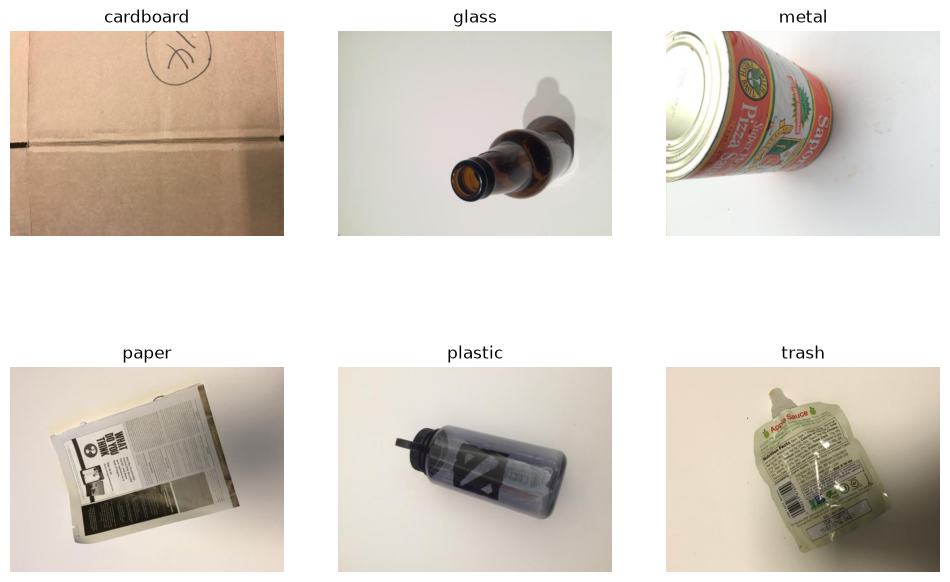

In [6]:
#Show sample images
import matplotlib.pyplot as plt
from PIL import Image

folders = os.listdir(dataset_path)

plt.figure(figsize=(12, 8))

for i, folder in enumerate(folders):
    path = os.path.join(dataset_path, folder)
    image_name = os.listdir(path)[0]
    image = Image.open(os.path.join(path, image_name))

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(folder)
    plt.axis("off")

plt.show()

In [7]:
for folder in os.listdir(dataset_path):
    path = os.path.join(dataset_path, folder)
    image_name = os.listdir(path)[0]
    image = Image.open(os.path.join(path, image_name))
    
    print(folder, ":", image.size)

cardboard : (512, 384)
glass : (512, 384)
metal : (512, 384)
paper : (512, 384)
plastic : (512, 384)
trash : (512, 384)


In [8]:
#Load and Resize Images
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_data = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="training",
    seed=123
)

val_data = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="validation",
    seed=123
)

Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.


In [9]:
print(train_data.class_names)

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [10]:
#Normalize the Images
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_data = train_data.map(
    lambda x, y: (normalization_layer(x), y)
)

val_data = val_data.map(
    lambda x, y: (normalization_layer(x), y)
)

print("Normalization completed!")

Normalization completed!


In [11]:
#Image Augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])


print("Image augmentation created!")

Image augmentation created!


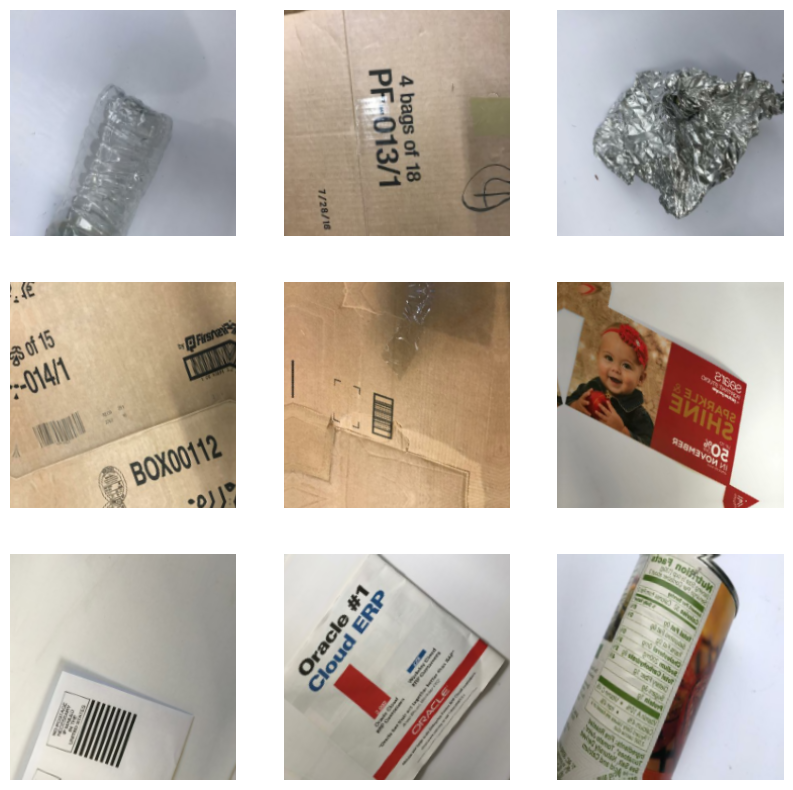

In [12]:
import matplotlib.pyplot as plt

for images, labels in train_data.take(1):
    plt.figure(figsize=(10, 10))

    for i in range(9):
        augmented_image = data_augmentation(images[i])

        plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_image.numpy())
        plt.axis("off")

    plt.show()

In [14]:
#Create the CNN Model

import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)),
    
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),

    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(6, activation="softmax")
])

print("CNN model created successfully!")

CNN model created successfully!


In [15]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [16]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ random_flip_2 (RandomFlip)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_rotation_2 (RandomRotation)   │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_zoom_2 (RandomZoom)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
#Train the CNN
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5


C:\Users\mchar\Ana 1\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


64/64 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - accuracy: 0.2715 - loss: 1.8153 - val_accuracy: 0.3802 - val_loss: 1.4914
Epoch 2/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.3858 - loss: 1.5232 - val_accuracy: 0.4416 - val_loss: 1.4247
Epoch 3/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 0.4407 - loss: 1.3955 - val_accuracy: 0.4693 - val_loss: 1.3222
Epoch 4/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.4713 - loss: 1.3384 - val_accuracy: 0.5050 - val_loss: 1.2892
Epoch 5/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.4758 - loss: 1.3190 - val_accuracy: 0.3980 - val_loss: 1.4507


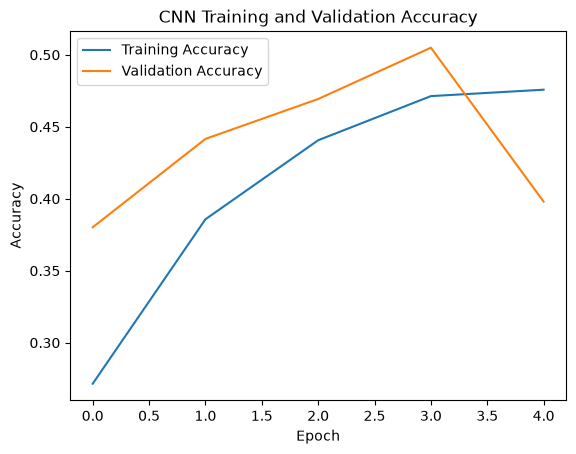

In [19]:
#Plot Training Accuracy
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training and Validation Accuracy")

plt.legend()
plt.show()

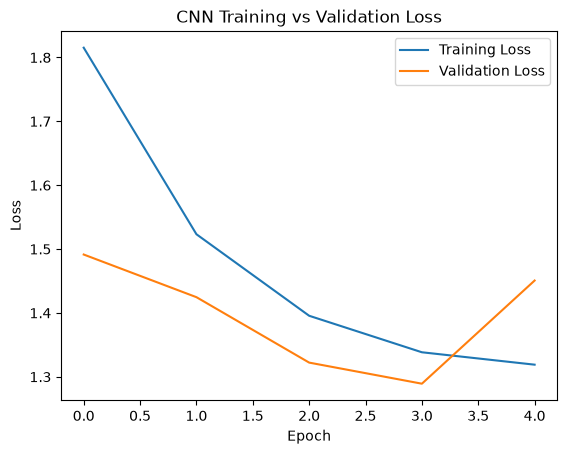

In [20]:
#Check Training & Validation Loss
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training vs Validation Loss")
plt.legend()

plt.show()

In [21]:
#Evaluate the CNN
loss, accuracy = model.evaluate(val_data)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 147ms/step - accuracy: 0.3980 - loss: 1.4507
Validation Loss: 1.4507137537002563
Validation Accuracy: 0.39801979064941406


In [22]:
#Precision, Recall & F1-Score
from sklearn.metrics import classification_report
import numpy as np

class_names = [
    "cardboard",
    "glass",
    "metal",
    "paper",
    "plastic",
    "trash"
]

y_true = []
y_pred = []

for images, labels in val_data:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

   cardboard       0.83      0.24      0.37        83
       glass       0.50      0.19      0.28       103
       metal       0.34      0.64      0.44        78
       paper       0.44      0.48      0.46       124
     plastic       0.33      0.58      0.42        88
       trash       0.00      0.00      0.00        29

    accuracy                           0.40       505
   macro avg       0.41      0.36      0.33       505
weighted avg       0.46      0.40      0.37       505



C:\Users\mchar\Ana 1\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\mchar\Ana 1\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\mchar\Ana 1\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


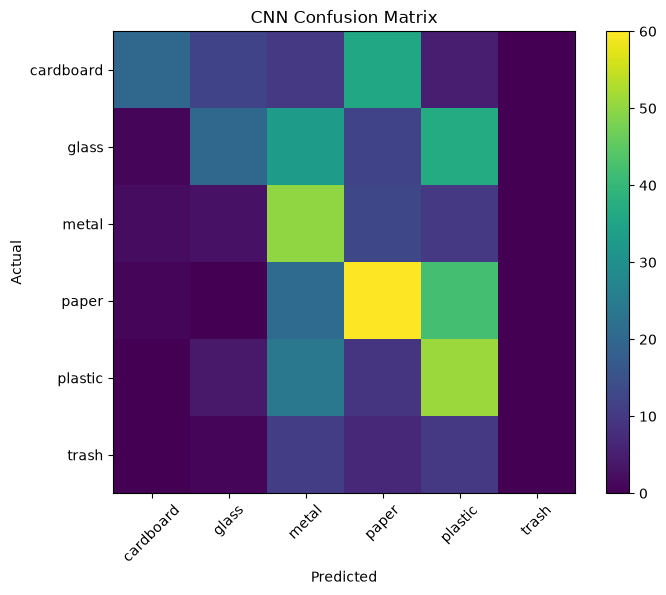

In [23]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix


cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))

plt.imshow(cm)

plt.xticks(range(6), class_names, rotation=45)
plt.yticks(range(6), class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")

plt.colorbar()

plt.show()

In [24]:
#save cnn model
model.save("../models/cnn_garbage_classifier.keras")

print("CNN model saved successfully!")

CNN model saved successfully!


In [25]:
#Load MobileNetV2
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

print("MobileNetV2 loaded successfully!")

MobileNetV2 loaded successfully!


In [26]:
#Freeze MobileNetV2
base_model.trainable = False

print("MobileNetV2 layers frozen!")

MobileNetV2 layers frozen!


In [26]:
#Build the MobileNetV2 Model
mobilenet_model = tf.keras.Sequential([
    
    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(128, activation="relu"),

    
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(6, activation="softmax")
])

print("MobileNetV2 model created successfully!")

MobileNetV2 model created successfully!


In [27]:
#Compile the MobileNetV2 Model
mobilenet_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("MobileNetV2 model compiled successfully!")

MobileNetV2 model compiled successfully!


In [28]:
#Train MobileNetV2
mobilenet_history = mobilenet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10


C:\Users\mchar\Ana 1\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


64/64 ━━━━━━━━━━━━━━━━━━━━ 59s 822ms/step - accuracy: 0.6014 - loss: 1.0679 - val_accuracy: 0.7287 - val_loss: 0.7059
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 51s 790ms/step - accuracy: 0.7596 - loss: 0.6509 - val_accuracy: 0.8040 - val_loss: 0.5349
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 75s 689ms/step - accuracy: 0.8111 - loss: 0.5339 - val_accuracy: 0.8158 - val_loss: 0.5065
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 48s 740ms/step - accuracy: 0.8526 - loss: 0.4212 - val_accuracy: 0.8059 - val_loss: 0.4981
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 49s 764ms/step - accuracy: 0.8625 - loss: 0.3973 - val_accuracy: 0.8495 - val_loss: 0.4755
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 54s 846ms/step - accuracy: 0.8853 - loss: 0.3312 - val_accuracy: 0.8238 - val_loss: 0.4796
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 70s 653ms/step - accuracy: 0.9011 - loss: 0.2771 - val_accuracy: 0.8277 - val_loss: 0.4744
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 50s 774ms/step - accuracy: 0.9065 - loss: 0.2641 - val_accuracy: 0.847

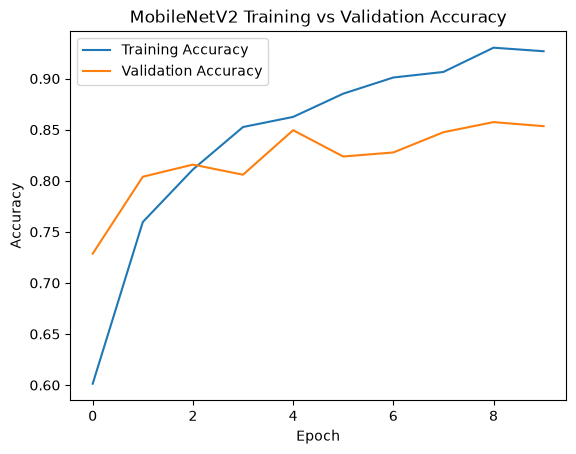

In [29]:
#MobileNetV2 Accuracy Graph

plt.plot(
    mobilenet_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    mobilenet_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 Training vs Validation Accuracy")

plt.legend()
plt.show()

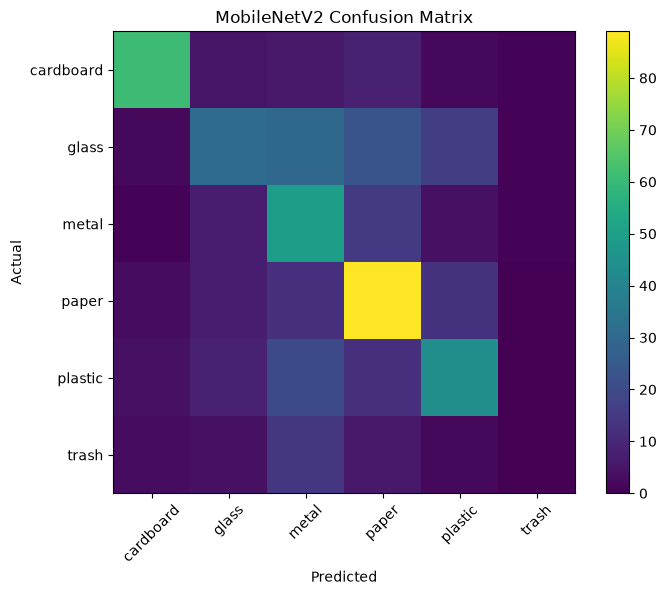

In [30]:
#MobileNetV2 Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))

plt.imshow(cm)

plt.xticks(range(6), class_names, rotation=45)
plt.yticks(range(6), class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MobileNetV2 Confusion Matrix")

plt.colorbar()

plt.show()

In [31]:
#Save
mobilenet_model.save("../models/mobilenetv2_garbage_classifier.keras")

print("MobileNetV2 model saved successfully!")

MobileNetV2 model saved successfully!


In [32]:
#Model Comparison.
#CNN predictions
cnn_true = []
cnn_pred = []

for images, labels in val_data:
    predictions = model.predict(images, verbose=0)

    cnn_true.extend(labels.numpy())
    cnn_pred.extend(np.argmax(predictions, axis=1))

cnn_report = classification_report(
    cnn_true,
    cnn_pred,
    target_names=class_names,
    output_dict=True
)


# MobileNetV2 predictions
mobile_true = []
mobile_pred = []

for images, labels in val_data:
    predictions = mobilenet_model.predict(images, verbose=0)

    mobile_true.extend(labels.numpy())
    mobile_pred.extend(np.argmax(predictions, axis=1))

mobile_report = classification_report(
    mobile_true,
    mobile_pred,
    target_names=class_names,
    output_dict=True
)


print("CNN F1-score:",
      cnn_report["weighted avg"]["f1-score"])

print("MobileNetV2 F1-score:",
      mobile_report["weighted avg"]["f1-score"])

CNN F1-score: 0.526430689918666
MobileNetV2 F1-score: 0.8524653208822947


In [33]:
#Comparison table

comparison = pd.DataFrame({
    "Model": ["CNN", "MobileNetV2"],
    
    "Accuracy": [
        cnn_report["accuracy"],
        mobile_report["accuracy"]
    ],
    
    "Precision": [
        cnn_report["weighted avg"]["precision"],
        mobile_report["weighted avg"]["precision"]
    ],
    
    "Recall": [
        cnn_report["weighted avg"]["recall"],
        mobile_report["weighted avg"]["recall"]
    ],
    
    "F1-Score": [
        cnn_report["weighted avg"]["f1-score"],
        mobile_report["weighted avg"]["f1-score"]
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,CNN,0.544554,0.533461,0.544554,0.526431
1,MobileNetV2,0.853465,0.853753,0.853465,0.852465


In [34]:
#Model Selection
best_model_name = comparison.loc[
    comparison["F1-Score"].idxmax(),
    "Model"
]

print("Selected model based on F1-score:", best_model_name)

Selected model based on F1-score: MobileNetV2


In [35]:
#final model
if best_model_name == "CNN":
    final_model = model
else:
    final_model = mobilenet_model

print("Final model:", best_model_name)

Final model: MobileNetV2


In [36]:
#Save
final_model.save("../models/final_garbage_classifier.keras")

print("final model saved successfully!")

final model saved successfully!
